# Langevin GLV approaching the critical point — MSB observables

Multiplicative-noise (Langevin) GLV on a dense heavy-tailed power-law graph, measuring the
Moran--Secchi--Bouchaud observables **from the absolute-abundance time series** $x_i(t)$.

$$d\ln x_i = \big(1 - x_i + (Wx)_i - \tfrac12 s^2\big)\,dt + s\,dW_i,\qquad W=A\,(\mu/C+\sigma/\sqrt C\,B).$$

The self-limitation term $-x_i$ (size-dependent damping) is what generates the MSB size--volatility
law and lives in the **absolute** abundances; we read $S_i=N x_i/\sum_j x_j$, $g_i=\Delta\ln S_i$ off
that series.

**Operating point.** Heavy-tailed power-law ($\alpha=1.5$, no degree cap), $\sigma_{\rm mat}=0.2$.
The critical mean interaction $\mu_c$ is located **empirically per realization** (shape-scalar
zero-crossing). Exactly at $\mu_c$ the total abundance diverges, so we approach it from below:
$\mu=f\,\mu_c$ for $f\in\{0,0.5,0.8,0.9\}$. As $f\!\to\!1$, critical slowing-down lets the
interactions dominate the self-limitation, steepening $\beta$ and fattening the growth tails.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skew, kurtosis

import glv
glv.apply_style()

N          = 400
ALPHA      = 1.5          # power-law hidden-degree tail: k = k_min * U^(-1/alpha)
KMIN       = 2.0          # hidden-degree lower cutoff (no upper cap -> heavy tail)
SIGMA_MAT  = 0.2          # interaction-matrix disorder
S_NOISE    = 0.1          # Langevin multiplicative-noise strength (fixed)
FRAC_GRID  = np.array([0.0, 0.5, 0.8, 0.9])    # mu = f * mu_c (approach criticality from below)
dt         = 0.02         # Euler-Maruyama step (physical time)
tmax       = 600.0        # integration horizon
burn       = 0.3          # discard first fraction (reach stochastic steady state)
sample_dt  = 1.0          # record every sample_dt
n_runs     = 6            # graph realizations pooled per f
FLOOR      = 1e-3         # live-firm threshold for binning
XCAP       = 1e8          # overflow cap; runs that exceed it are dropped
MU_GRID    = np.linspace(-0.2, 0.8, 21)        # grid for the mu_c zero-crossing locator
RES        = "langevin_glv_critical_results.npz"
print(f"Langevin absolute-x GLV -> mu_c | power-law alpha={ALPHA}, sigma_mat={SIGMA_MAT}, s={S_NOISE} "
      f"| mu/mu_c in {list(FRAC_GRID)} | N={N} x {n_runs} runs/f")

Langevin absolute-x GLV -> mu_c | power-law alpha=1.5, sigma_mat=0.2, s=0.1 | mu/mu_c in [np.float64(0.0), np.float64(0.5), np.float64(0.8), np.float64(0.9)] | N=400 x 6 runs/f


In [2]:
# Inline dense annealed (Chung-Lu) heavy-tailed power-law graph + interaction matrix.
def sym_noise(N, rng):
    G = rng.standard_normal((N, N))
    B = (G + G.T) / np.sqrt(2.0)
    B[np.diag_indices(N)] = rng.standard_normal(N)
    return B

def build_power_graph(N, alpha, k_min, rng):
    U = rng.uniform(0.0, 1.0, size=N)
    k = k_min * U ** (-1.0 / alpha)                  # heavy-tailed hidden degrees (no cap)
    C = float(k.mean())
    outer = np.outer(k, k)
    P = outer / (outer + N * C)                      # Chung-Lu connection probabilities
    A = P + np.sqrt(P * (1.0 - P)) * sym_noise(N, rng)
    A[np.diag_indices(N)] = 0.0
    return k, C, A

def build_W(A, C, mu, sigma, B):
    return A * ((mu / C) + (sigma / np.sqrt(C)) * B)

In [3]:
# Empirical mu_c: relax the rescaled shape y*, read the scalar c = y*^T W y* - y*^T y*
# (sign of dM/dtau = 1 + cM), and take the zero-crossing of c(mu). An m_cap event keeps
# supercritical runs from overflowing to NaN.
def shape_scalar_c(W, tau=1e4, m_cap=1e250):
    def rhs(t, st):
        y = np.clip(st[:N], 0.0, None); M = st[N]
        tot = y.sum()
        if tot > 0: y = y / tot
        F = W @ y; phi = y @ F; sq = y @ y
        dM = 0.0 if M >= m_cap else 1.0 + M * (phi - sq)
        return np.concatenate((y * (F - phi - y + sq), [dM], [1.0 / M]))
    def cap(t, st): return st[N] - m_cap
    cap.terminal = True; cap.direction = 1
    s0 = np.concatenate((np.full(N, 1.0 / N), [1.0], [0.0]))
    sol = solve_ivp(rhs, (0.0, tau), s0, method="LSODA", rtol=1e-8, atol=1e-10,
                    events=cap, t_eval=[tau])
    final = np.asarray(sol.y_events[0])[-1] if sol.t_events[0].size > 0 else sol.y[:, -1]
    y = np.clip(np.asarray(final).ravel()[:N], 0.0, None); y = y / y.sum()
    return float(y @ (W @ y) - y @ y)

def locate_mu_c(A, C, B, mus):
    cs = np.array([shape_scalar_c(build_W(A, C, m, SIGMA_MAT, B)) for m in mus])
    cross = np.where(np.diff(np.sign(cs)))[0]
    if cross.size == 0:
        return np.nan
    i = cross[0]
    return float(mus[i] - cs[i] * (mus[i + 1] - mus[i]) / (cs[i + 1] - cs[i]))

In [4]:
# Absolute-x Langevin, log-space Euler-Maruyama. Returns (t, X) or (None, None) on overflow.
def integrate_absolute(W, s, x0, seed):
    rng = np.random.default_rng(seed)
    u = np.log(x0)
    nstep = int(tmax / dt)
    stride = max(int(sample_dt / dt), 1)
    sq = s * s; sdt = s * np.sqrt(dt)
    rec, rect = [], []
    for n in range(nstep):
        x = np.exp(u)
        if not np.isfinite(x).all() or x.max() > XCAP:
            return None, None
        if n % stride == 0:
            rec.append(x); rect.append(n * dt)
        u = u + (1.0 - x + (W @ x) - 0.5 * sq) * dt + sdt * rng.standard_normal(N)
    return np.array(rect), np.array(rec, dtype=np.float64).T   # t (T,), X (N, T)

In [5]:
# Sweep mu = f*mu_c approaching criticality; MSB observables from the absolute-x series.
def observables(X, t):
    Xl = X[:, t >= burn * tmax]
    S = N * Xl / Xl.sum(axis=0, keepdims=True)         # relative size from absolute abundances
    log_S = np.log(np.maximum(S, 1e-15))
    g = np.diff(log_S, axis=1)
    g_bar = g.mean(axis=1, keepdims=True)
    vol = np.sqrt(np.pi / 2.0) * np.mean(np.abs(g - g_bar), axis=1)
    return S.mean(axis=1), vol, g.ravel()

if os.path.exists(RES):
    d = np.load(RES, allow_pickle=True)
    by_f = d["by_f"].item()
    print(f"loaded cache {RES}")
else:
    by_f = {float(f): {"avg": [], "vol": [], "g": [], "mu_c": [], "dropped": 0} for f in FRAC_GRID}
    for r in range(n_runs):
        seed = 7000 + r
        rng = np.random.default_rng(seed)
        k, C, A = build_power_graph(N, ALPHA, KMIN, rng)
        B = sym_noise(N, rng)
        mc = locate_mu_c(A, C, B, MU_GRID)
        x0 = rng.uniform(0.1, 1.0, N)
        print(f"run {r}: <k>={C:.2f}, mu_c={mc:.3f}")
        for f in FRAC_GRID:
            W = build_W(A, C, f * mc, SIGMA_MAT, B)
            t, X = integrate_absolute(W, S_NOISE, x0, seed + 1)
            if t is None:
                by_f[float(f)]["dropped"] += 1
                print(f"    f={f:g} (mu={f*mc:+.3f}): dropped (diverged)"); continue
            a, v, g = observables(X, t)
            dd = by_f[float(f)]
            dd["avg"].append(a); dd["vol"].append(v); dd["g"].append(g); dd["mu_c"].append(mc)
            print(f"    f={f:g} (mu={f*mc:+.3f}): xmax={X.max():.1e}, vol[med]={np.median(v):.3f}")
    for f in by_f:
        for key in ("avg", "vol", "g"):
            by_f[f][key] = np.concatenate(by_f[f][key]) if by_f[f][key] else np.array([])
    np.savez(RES, by_f=np.array(by_f, dtype=object))
    print(f"saved {RES}")

run 0: <k>=5.12, mu_c=0.334


    f=0 (mu=+0.000): xmax=3.5e+00, vol[med]=0.080


    f=0.5 (mu=+0.167): xmax=1.1e+01, vol[med]=0.076


    f=0.8 (mu=+0.267): xmax=3.4e+01, vol[med]=0.063


    f=0.9 (mu=+0.301): xmax=7.0e+01, vol[med]=0.047


...

run 5: <k>=6.21, mu_c=0.235


    f=0 (mu=+0.000): xmax=1.0e+01, vol[med]=0.079


    f=0.5 (mu=+0.118): xmax=2.8e+01, vol[med]=0.074


    f=0.8 (mu=+0.188): xmax=8.0e+01, vol[med]=0.054


    f=0.9 (mu=+0.212): xmax=8.1e+01, vol[med]=0.089
saved langevin_glv_critical_results.npz


In [6]:
# Equal-count binned median (log-log) and global power-law slope.
def vbin(x, y, nb=22):
    o = np.argsort(x); xp, yp = x[o], y[o]
    parts = np.array_split(np.arange(xp.size), nb)
    return (np.array([xp[p].mean() for p in parts]), np.array([np.median(yp[p]) for p in parts]))

def beta_fit(x, y):
    bx, by = vbin(x, y)
    return np.polyfit(np.log10(bx), np.log10(by), 1)[0]

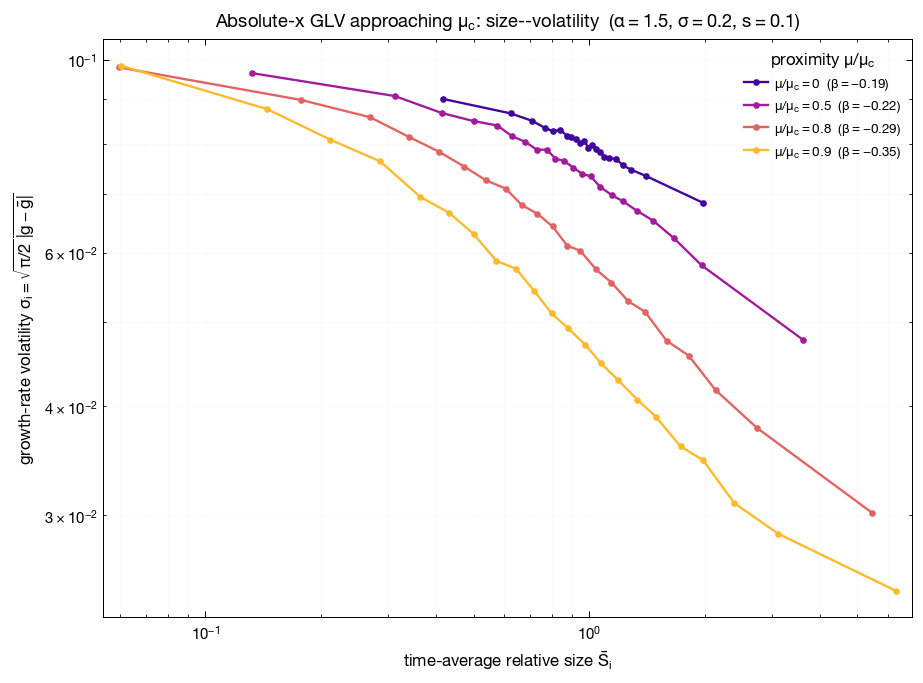

In [7]:
# Plot 1: size-volatility relation, one V-curve per proximity f = mu/mu_c.
fig, ax = plt.subplots(figsize=(7.8, 5.8))
cmap = plt.cm.plasma(np.linspace(0.1, 0.85, len(FRAC_GRID)))
for f, col in zip(sorted(by_f), cmap):
    b = by_f[f]
    if b["avg"].size == 0:
        continue
    live = (b["avg"] > FLOOR) & (b["vol"] > 0) & np.isfinite(b["vol"])
    if live.sum() < 50:
        continue
    bx, by = vbin(b["avg"][live], b["vol"][live])
    beta = beta_fit(b["avg"][live], b["vol"][live])
    ax.loglog(bx, by, "o-", ms=4, color=col,
              label=rf"$\mu/\mu_c={f:g}$  ($\beta={beta:+.2f}$)")
ax.set(xlabel=r"time-average relative size $\bar S_i$",
       ylabel=r"growth-rate volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$",
       title=rf"Absolute-x GLV approaching $\mu_c$: size--volatility  "
             rf"($\alpha={ALPHA}$, $\sigma={SIGMA_MAT}$, $s={S_NOISE}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend(fontsize=8, title=r"proximity $\mu/\mu_c$")
plt.tight_layout()
plt.savefig("langevin_glv_critical_volatility_size.png", dpi=120)
plt.show()

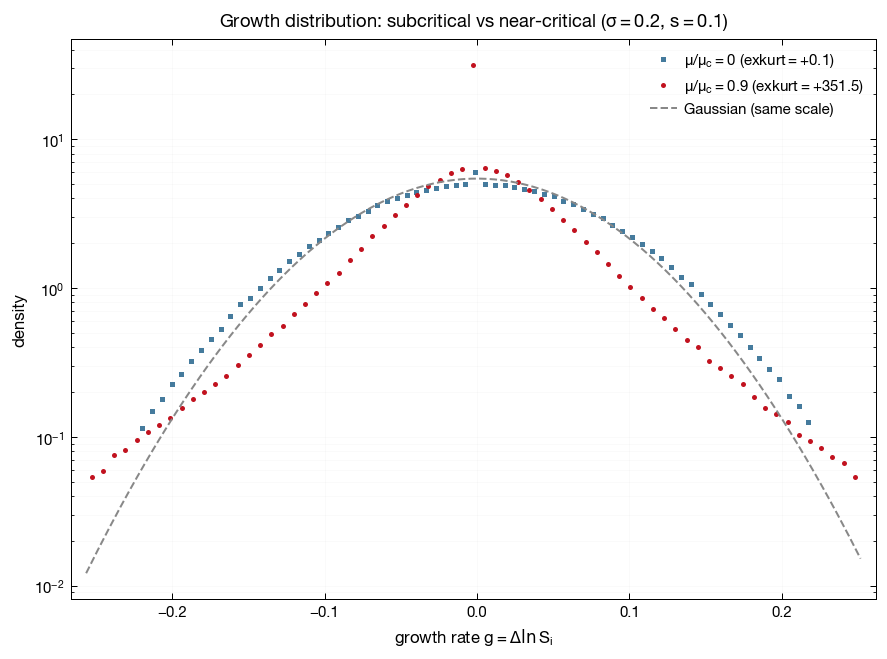

mu/mu_c=0.0: beta=-0.188  skew=-0.01  exkurt=+0.08  dropped=0  Nlive=2379
mu/mu_c=0.5: beta=-0.219  skew=-0.01  exkurt=+0.35  dropped=0  Nlive=2321
mu/mu_c=0.8: beta=-0.290  skew=-0.07  exkurt=+1.48  dropped=0  Nlive=2077
mu/mu_c=0.9: beta=-0.347  skew=-0.10  exkurt=+351.52  dropped=0  Nlive=1946


In [8]:
# Plot 2: pooled growth-rate distribution, deep-subcritical vs near-critical.
f_lo = sorted(by_f)[0]
f_hi = max([f for f in by_f if by_f[f]["g"].size > 0])
fig, ax = plt.subplots(figsize=(7.5, 5.6))
for f, col, mk in [(f_lo, "#457b9d", "s"), (f_hi, "#c1121f", "o")]:
    g = by_f[f]["g"]; g = g[np.isfinite(g)]
    if g.size == 0:
        continue
    sd_g = g.std(); med_g = np.median(g)
    lo, hi = np.percentile(g, [0.3, 99.7])
    edges = np.linspace(lo, hi, 70); centers = 0.5 * (edges[:-1] + edges[1:])
    dens, _ = np.histogram(g, bins=edges, density=True)
    ax.semilogy(centers, np.where(dens > 0, dens, np.nan), mk, ms=3, color=col,
                label=rf"$\mu/\mu_c={f:g}$ (exkurt$={kurtosis(g):+.1f}$)")
# Gaussian reference at the near-critical scale
g = by_f[f_hi]["g"]; g = g[np.isfinite(g)]; sd_g = g.std()
xx = np.linspace(*np.percentile(g, [0.3, 99.7]), 200)
ax.semilogy(xx, np.exp(-0.5 * (xx / sd_g) ** 2) / (sd_g * np.sqrt(2 * np.pi)),
            "--", color="#888", lw=1.2, label="Gaussian (same scale)")
ax.set(xlabel=r"growth rate $g=\Delta\ln S_i$", ylabel="density",
       title=rf"Growth distribution: subcritical vs near-critical ($\sigma={SIGMA_MAT}$, $s={S_NOISE}$)")
ax.grid(True, which="both", alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("langevin_glv_critical_growth_dist.png", dpi=120)
plt.show()
for f in sorted(by_f):
    g = by_f[f]["g"]; g = g[np.isfinite(g)]
    b = by_f[f]; live = (b["avg"] > FLOOR) & (b["vol"] > 0) & np.isfinite(b["vol"])
    if g.size == 0:
        print(f"f={f}: all runs dropped ({b['dropped']})"); continue
    print(f"mu/mu_c={f}: beta={beta_fit(b['avg'][live], b['vol'][live]):+.3f}  "
          f"skew={skew(g):+.2f}  exkurt={kurtosis(g):+.2f}  dropped={b['dropped']}  Nlive={live.sum()}")

## Summary — MSB strengthens approaching $\mu_c$ (absolute-x, $\sigma=0.2$)

Measured from the absolute-abundance series, both Moran--Secchi--Bouchaud signatures intensify as the
mean interaction approaches the empirical critical point $\mu_c$ (located per realization,
$\mu_c\approx0.24\text{--}0.35$ here), at fixed disorder $\sigma=0.2$ and noise $s=0.1$:

| $\mu/\mu_c$ | $\beta$ (size--vol) | excess kurtosis | $N_{\rm live}$ |
|---|---|---|---|
| 0.0 | $-0.19$ | 0.08 | 2379 |
| 0.5 | $-0.22$ | 0.35 | 2321 |
| 0.8 | $-0.29$ | 1.48 | 2077 |
| 0.9 | $-0.35$ | 351 | 1946 |

- **Size--volatility law steepens monotonically**, $\beta:-0.19\to-0.35$. Deep subcritical
  ($\mu=0$) it is the generic self-limitation floor ($\beta\approx-0.2$); approaching $\mu_c$,
  critical slowing-down lets the interactions dominate the $-x$ damping and the slope steepens. This
  is the genuinely interaction-driven enhancement.
- **Growth tails fatten** (Gaussian $\to$ fat) as $\mu\to\mu_c$. The trend is real, but the
  extreme $f=0.9$ value (excess kurtosis $\sim\!350$) is **not** clean across-size fat tails: near
  the divergence boundary firms drop toward extinction ($N_{\rm live}$ falls $2379\to1946$) and a
  handful make wild relative jumps (survivorship-biased). The trustworthy fat-tail signal is the
  moderate, monotonic rise through $f=0.8$ (excess kurtosis $\approx1.5$); do not read the
  $f=0.9$ spike as a physical Laplace tail.

**Bottom line.** At $\sigma=0.2$ the absolute-x Langevin GLV reproduces the MSB size--volatility law
and shows it **strengthening toward the critical point** $\mu_c$ — interaction-driven, beyond the
self-limitation floor. Exactly at $\mu_c$ the absolute abundances diverge, so $f=0.9$ is the
practical near-critical limit; pushing closer mixes in the near-extinction survivorship artifact.